In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import stream as st
import bonesistools as bt

import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
import matplotlib.ticker as mtick
bt.sct.pl.set_default_params()

In [2]:
adata = st.read(file_name="data/hematopoiesis/stream/mstates.h5ad.pkl")
st.set_workdir(adata, "data/hematopoiesis/stream")

Working directory is already specified as '/home/roncalli/Documents/these/scbridge/nestorowa/unique/mstates/stream' 
To change working directory, please run set_workdir(adata,workdir=new_directory)
Saving results in: data/hematopoiesis/stream


In [3]:
adata.uns["label_color"] = {
    "HSC" : bt.sct.pl.get_color("black"),
    "MPP" : bt.sct.pl.get_color("gray"),
    "LMPP": bt.sct.pl.get_color("teal"),
    "CMP" : bt.sct.pl.get_color("orange"),
    "MEP" : bt.sct.pl.get_color("darkred"),
    "GMP" : bt.sct.pl.get_color("gold")
}
label_order = ["HSC", "MPP", "LMPP", "CMP", "MEP", "GMP"]

macro_order = sorted(adata.obs["macrostate"].cat.categories)
macro_color = {macrostate: color for macrostate, color in zip(macro_order, bt.sct.pl.COLORS[:len(macro_order)])}

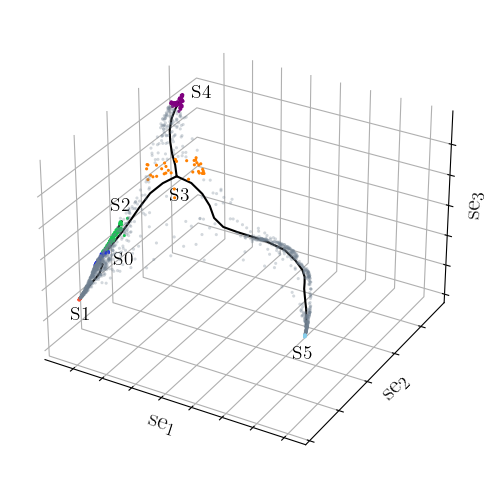

In [4]:
embedding_label = "se"
fig, ax = bt.sct.pl.embedding_plot(
    adata,
    obs="macrostate",
    colors=macro_color,
    use_rep="X_se",
    xlabel=r"$\mathrm{{{}_{{1}}}}$".format(embedding_label),
    ylabel=r"$\mathrm{{{}_{{2}}}}$".format(embedding_label),
    zlabel=r"$\mathrm{{{}_{{3}}}}$".format(embedding_label),
    figwidth=6,
    fontsize=14,
    s=5,
    alpha=1.0,
    add_legend=False,
    text={
        "fontsize":14,
        "fontweight":"extra bold"
    },
    add_graph=True,
    add_labels_to_graph=True,
    n_components=3,
    background_visible=False,
    tick_params = {
        "which": "both",
        "bottom": False,
        "top": False,
        "left": False,
        "right": False,
        "labelbottom": False,
        "labelleft": False
    }
)
ax.xaxis.labelpad = -10
ax.yaxis.labelpad = -10
ax.zaxis.labelpad = -10
ax.set_xlabel(ax.get_xlabel(), fontsize=18)
ax.set_ylabel(ax.get_ylabel(), fontsize=18)
ax.set_zlabel(ax.get_zlabel(), fontsize=18)

for txt in ax.texts:
    x, y = txt.get_position()
    label = txt.get_text()
    if label == "S0":
        txt.set_position((x + 0.0015, y - 0.001))
    elif label == "S1":
        txt.set_position((x + 0.001, y - 0.003))
    elif label == "S2":
        txt.set_position((x - 0.0015, y + 0.001))
    elif label == "S3":
        txt.set_position((x + 0.0015, y - 0.004))
    elif label == "S4":
        txt.set_position((x + 0.0008, y))
    elif label == "S5":
        txt.set_position((x + 0.0007, y - 0.0033))

fig.tight_layout()

#plt.savefig(
#    "se_macrostates.pdf",
#    dpi=300,
#    bbox_inches="tight",
#    pad_inches=-0.2
#)

plt.show()

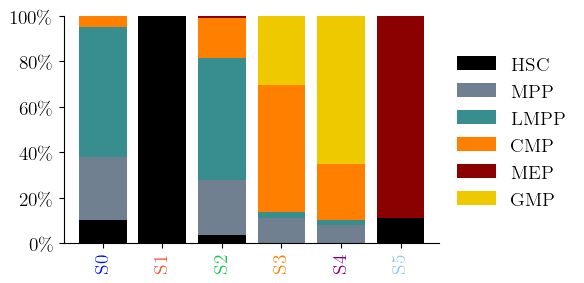

In [5]:
macro_order = ["S0", "S1", "S2", "S3", "S4", "S5"]

df = adata.obs[["macrostate", "label"]].dropna()

counts = pd.crosstab(df["macrostate"], df["label"])
counts = counts.reindex(index=macro_order, columns=label_order, fill_value=0)

props = counts.div(counts.sum(axis=1), axis=0)

ax = props.plot(
    kind="bar",
    stacked=True,
    figsize=(6, 3),
    width=0.8,
    color=[adata.uns["label_color"][label] for label in label_order]
)

ax.set_xlabel("")
for ticklabel in ax.get_xticklabels():
    state = ticklabel.get_text()
    ticklabel.set_color(macro_color[state])
    ticklabel.set_fontweight("bold")

ax.legend(
    bbox_to_anchor=(1.0, 0.9),
    loc="upper left",
    frameon=False,
    fontsize=14
)
ax.tick_params(axis="both", labelsize=14)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

#plt.savefig(
#    "cell_proportions.pdf",
#    dpi=300,
#    bbox_inches="tight",
#)

plt.tight_layout()
plt.show()

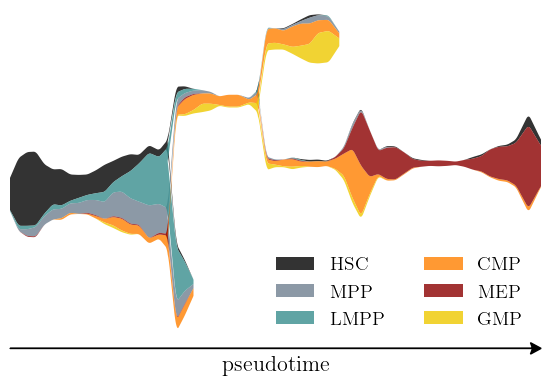

In [6]:
root = "S1"

st.plot_stream(
    adata,
    root=root,
    color=["label"],
    log_scale=False,
    factor_zoomin=100,
    save_fig=False,
    fig_legend_order={"label": label_order},
)

plt.title("")
plt.xticks([])

ax = plt.gca()

legend = ax.get_legend()
handles = legend.legendHandles
labels = [t.get_text() for t in legend.get_texts()]
legend.remove()
ax.legend(
    handles,
    labels,
    loc="lower right",
    bbox_to_anchor=(1.0, 0.05),
    ncol=2,
    fontsize=14,
    frameon=False
)

dy = +0.15
arrow = ax.get_children()[6]
arrow.set_transform(
    arrow.get_transform() + transforms.ScaledTranslation(
        0, dy, ax.figure.dpi_scale_trans
    )
)

ax.xaxis.set_label_coords(0.5, 0.02)
ax.xaxis.label.set_fontsize(16)
ax.spines["bottom"].set_visible(False)
ax.tick_params(axis="x", length=0)
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 0.85)

#plt.savefig(
#    "streamplot.pdf",
#    dpi=300,
#    bbox_inches="tight"
#)

plt.show()